In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu

In [2]:
df = pd.read_csv("//Users/zofiabrodewicz/Documents/GitHub/Bachelor/collaborations_with_distances.csv")
df["log_avg_streams"] = np.log10(df["avg_streams"])

## Exploratory analysis of the distances 


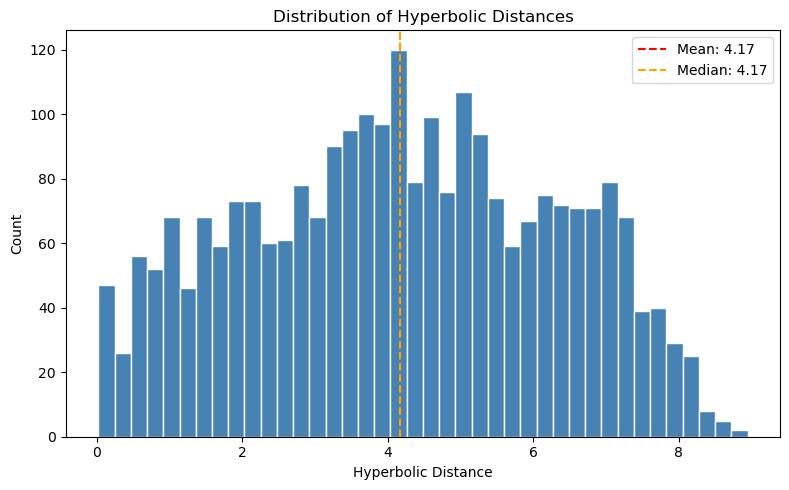

In [3]:
#  Plot 1: Distribution of distances 
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["hyperbolic_distance"], bins=40, color="steelblue", edgecolor="white")
ax.axvline(df["hyperbolic_distance"].mean(), color="red", linestyle="--",
           label=f'Mean: {df["hyperbolic_distance"].mean():.2f}')
ax.axvline(df["hyperbolic_distance"].median(), color="orange", linestyle="--",
           label=f'Median: {df["hyperbolic_distance"].median():.2f}')
ax.set_title("Distribution of Hyperbolic Distances")
ax.set_xlabel("Hyperbolic Distance")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()



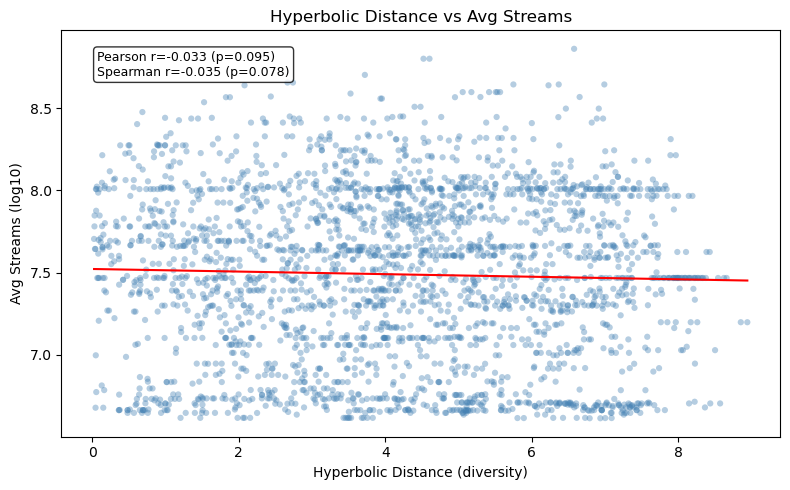

In [4]:
# Plot 2: Distance vs avg_streams 
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["hyperbolic_distance"], df["log_avg_streams"],
           alpha=0.4, color="steelblue", edgecolors="none", s=20)
z = np.polyfit(df["hyperbolic_distance"], df["log_avg_streams"], 1)
p = np.poly1d(z)
x_line = np.linspace(df["hyperbolic_distance"].min(), df["hyperbolic_distance"].max(), 100)
ax.plot(x_line, p(x_line), color="red", linewidth=1.5)
pearson_r, pearson_p = stats.pearsonr(df["hyperbolic_distance"], df["log_avg_streams"])
spearman_r, spearman_p = stats.spearmanr(df["hyperbolic_distance"], df["log_avg_streams"])
ax.set_title("Hyperbolic Distance vs Avg Streams")
ax.set_xlabel("Hyperbolic Distance (diversity)")
ax.set_ylabel("Avg Streams (log10)")
ax.text(0.05, 0.95,
        f"Pearson r={pearson_r:.3f} (p={pearson_p:.3f})\nSpearman r={spearman_r:.3f} (p={spearman_p:.3f})",
        transform=ax.transAxes, fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()


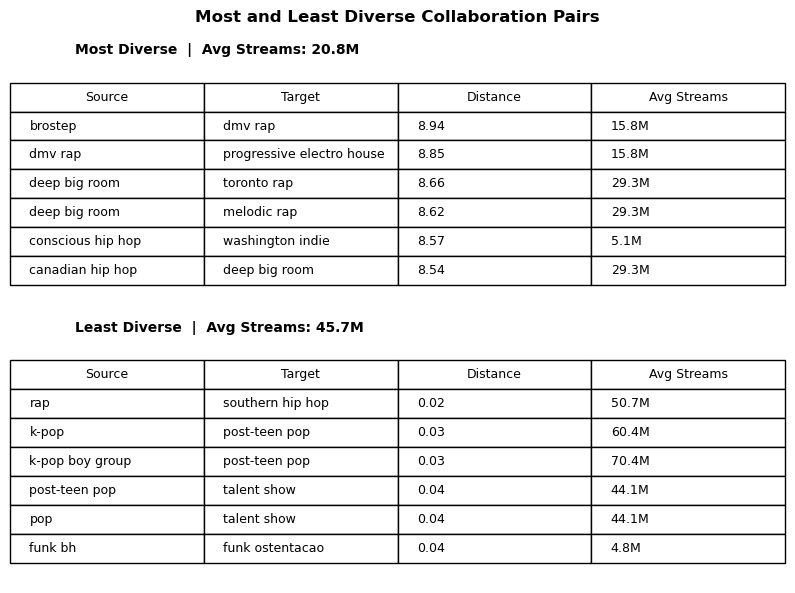

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))
fig.suptitle("Most and Least Diverse Collaboration Pairs",
             fontsize=12, fontweight="bold")

top_diverse = df.nlargest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]
top_similar = df.nsmallest(6, "hyperbolic_distance")[["source", "target", "hyperbolic_distance", "avg_streams"]]

# average streams per group
avg_streams_diverse = top_diverse["avg_streams"].mean()
avg_streams_similar = top_similar["avg_streams"].mean()

diverse_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_diverse.iterrows()]
similar_data = [[row["source"], row["target"],
                 f'{row["hyperbolic_distance"]:.2f}',
                 f'{row["avg_streams"]/1e6:.1f}M']
                for _, row in top_similar.iterrows()]

for ax, data, title, avg_streams in zip(
    axes,
    [diverse_data, similar_data],
    ["Most Diverse", "Least Diverse"],
    [avg_streams_diverse, avg_streams_similar]
):
    ax.axis("off")
    ax.set_title(f"{title}  |  Avg Streams: {avg_streams/1e6:.1f}M",
                 fontsize=10, fontweight="bold", loc="left")
    table = ax.table(cellText=data,
                     colLabels=["Source", "Target", "Distance", "Avg Streams"],
                     loc="center", cellLoc="left")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)

plt.tight_layout()
plt.show()

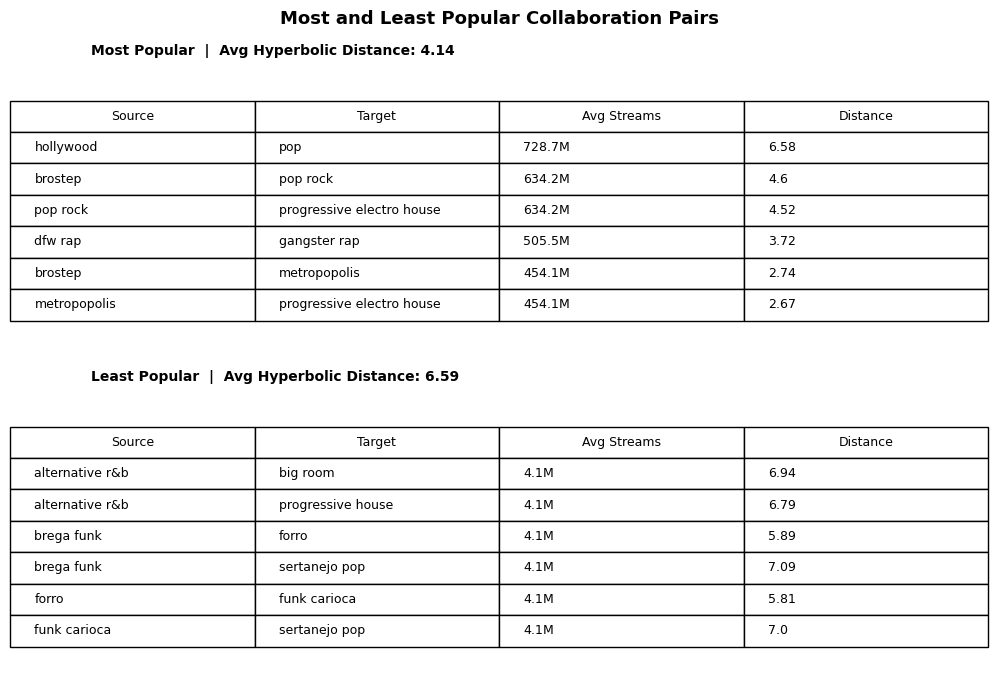

In [6]:
top_popular = df.nlargest(6, "avg_streams")[["source", "target", "avg_streams", "hyperbolic_distance"]].copy()
least_popular = df.nsmallest(6, "avg_streams")[["source", "target", "avg_streams", "hyperbolic_distance"]].copy()

def format_streams(val):
    return f"{val/1e6:.1f}M"

top_popular["avg_streams"] = top_popular["avg_streams"].apply(format_streams)
least_popular["avg_streams"] = least_popular["avg_streams"].apply(format_streams)
top_popular["hyperbolic_distance"] = top_popular["hyperbolic_distance"].round(2)
least_popular["hyperbolic_distance"] = least_popular["hyperbolic_distance"].round(2)

avg_dist_popular = df.nlargest(6, "avg_streams")["hyperbolic_distance"].mean()
avg_dist_least = df.nsmallest(6, "avg_streams")["hyperbolic_distance"].mean()


fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle("Most and Least Popular Collaboration Pairs", 
             fontsize=13, fontweight="bold")

for ax, data, title, avg_dist in zip(
    axes,
    [top_popular, least_popular],
    ["Most Popular", "Least Popular"],
    [avg_dist_popular, avg_dist_least]
):
    ax.axis("off")
    ax.set_title(f"{title}  |  Avg Hyperbolic Distance: {avg_dist:.2f}",
                 fontsize=10, fontweight="bold", loc="left", pad=8)
    
    table = ax.table(
        cellText=data.values,
        colLabels=["Source", "Target", "Avg Streams", "Distance"],
        loc="center",
        cellLoc="left"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.6)

plt.tight_layout()
plt.show()

## Looking at average streams and average diversity 

In [19]:
df = pd.read_csv("/Users/zofiabrodewicz/Documents/GitHub/Bachelor/collaborations_with_distances.csv")
df["log_avg_streams"] = np.log10(df["avg_streams"])

# assign groups
df["diversity_group"] = pd.qcut(
    df["hyperbolic_distance"],
    q=3,
    labels=["Low Diversity", "Medium Diversity", "High Diversity"]
)

# compute stats
group_stats = df.groupby("diversity_group").agg(
    n_pairs=("hyperbolic_distance", "count"),
    avg_distance=("hyperbolic_distance", "mean"),
    avg_streams=("avg_streams", "mean"),
    median_streams=("avg_streams", "median")
).reset_index()

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_30614/3676663670.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby("diversity_group").agg(


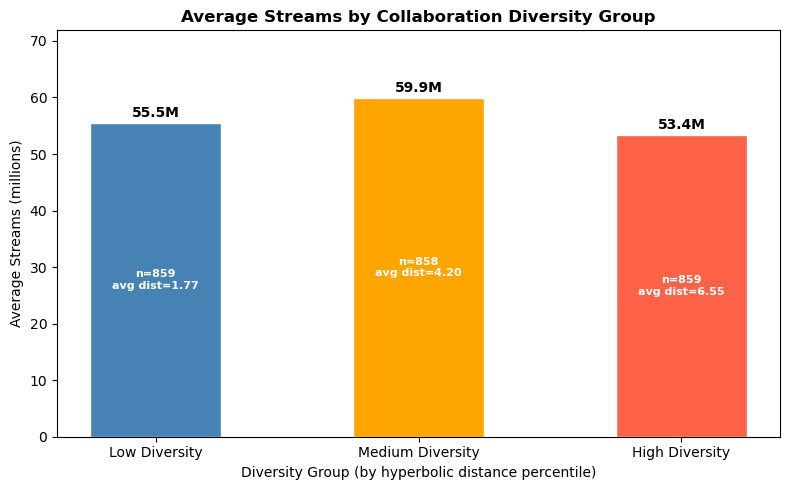

In [18]:
# plot 1: bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue", "orange", "tomato"]
bars = ax.bar(group_stats["diversity_group"],
              group_stats["avg_streams"] / 1e6,
              color=colors, edgecolor="white", width=0.5)

for bar, val in zip(bars, group_stats["avg_streams"] / 1e6):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}M",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

for bar, n, avg_d in zip(bars, group_stats["n_pairs"], group_stats["avg_distance"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f"n={n}\navg dist={avg_d:.2f}",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")

ax.set_title("Average Streams by Collaboration Diversity Group",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Diversity Group (by hyperbolic distance percentile)")
ax.set_ylabel("Average Streams (millions)")
ax.set_ylim(0, group_stats["avg_streams"].max() / 1e6 * 1.2)
plt.tight_layout()
plt.show()

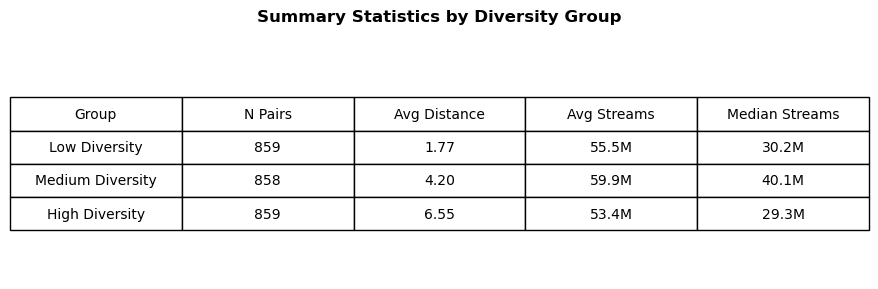

In [16]:
# plot 2: summary table
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis("off")
table_data = [
    [row["diversity_group"],
     f'{row["n_pairs"]}',
     f'{row["avg_distance"]:.2f}',
     f'{row["avg_streams"]/1e6:.1f}M',
     f'{row["median_streams"]/1e6:.1f}M']
    for _, row in group_stats.iterrows()
]
table = ax.table(
    cellText=table_data,
    colLabels=["Group", "N Pairs", "Avg Distance", "Avg Streams", "Median Streams"],
    loc="center", cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.3, 2.0)
ax.set_title("Summary Statistics by Diversity Group",
             fontsize=12, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [17]:
groups = [group["avg_streams"].values for _, group in df.groupby("diversity_group")]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis stat: {stat:.4f}, p-value: {p:.4f}")

Kruskal-Wallis stat: 6.3999, p-value: 0.0408


/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_30614/2229778871.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["avg_streams"].values for _, group in df.groupby("diversity_group")]


In [ ]:
low = df[df["diversity_group"] == "Low Diversity"]["avg_streams"]
med = df[df["diversity_group"] == "Medium Diversity"]["avg_streams"]
high = df[df["diversity_group"] == "High Diversity"]["avg_streams"]

stat1, p1 = mannwhitneyu(low, med, alternative="two-sided")
stat2, p2 = mannwhitneyu(low, high, alternative="two-sided")
stat3, p3 = mannwhitneyu(med, high, alternative="two-sided")

print(f"Low vs Medium:  p={p1:.4f}")
print(f"Low vs High:    p={p2:.4f}")
print(f"Medium vs High: p={p3:.4f}")

Low vs Medium:  p=0.1119
Low vs High:    p=0.3000
Medium vs High: p=0.0142


##### The medium diversity group has the smallest gap between average and median, meaning it has the most consistent performance. Low and high diversity groups have larger gaps, meaning their averages are pulled up by a few outlier mega-hits while most collaborations in those groups perform more modestly.

## Average diversity over the years

   year  n_pairs  mean_distance  median_distance  std_distance
0  2017     2432         4.2720           4.2140        2.1472
1  2018     2581         4.1210           4.0859        2.1045
2  2019     2576         4.1702           4.1723        2.1040

Kruskal-Wallis stat: 6.2050, p-value: 0.0449
Spearman correlation (year vs distance): r=-0.0169, p=0.1422


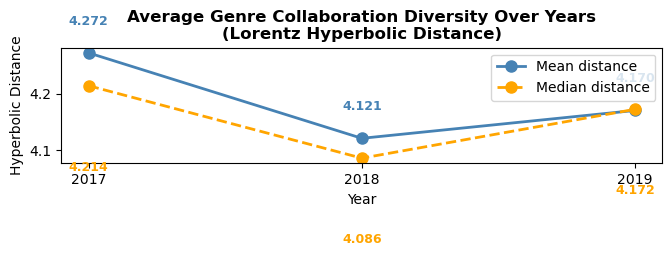

/var/folders/dg/b7mzgxb15dl8by7649q1jfj40000gp/T/ipykernel_30614/2991478974.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_year, labels=[2017, 2018, 2019],


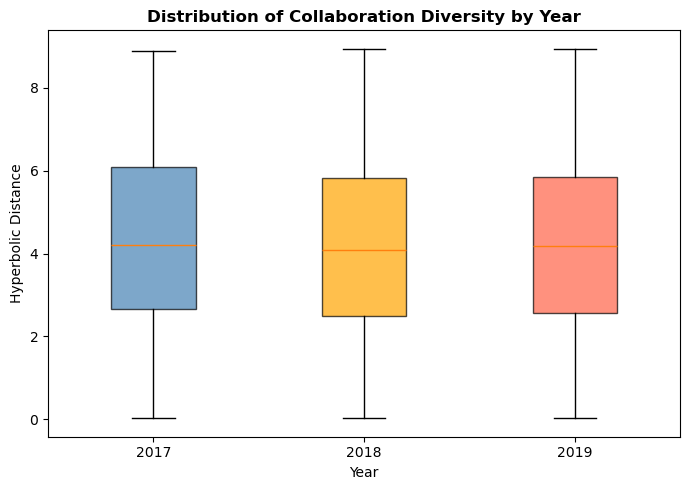

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── load all three years ──────────────────────────────────────────────────────
df_2017 = pd.read_csv("collaborations_with_distances2017.csv")
df_2018 = pd.read_csv("collaborations_with_distances2018.csv")
df_2019 = pd.read_csv("collaborations_with_distances2019.csv")

df_2017["year"] = 2017
df_2018["year"] = 2018
df_2019["year"] = 2019

all_years = pd.concat([df_2017, df_2018, df_2019], ignore_index=True)

# ── summary stats per year ────────────────────────────────────────────────────
summary = all_years.groupby("year").agg(
    n_pairs=("hyperbolic_distance", "count"),
    mean_distance=("hyperbolic_distance", "mean"),
    median_distance=("hyperbolic_distance", "median"),
    std_distance=("hyperbolic_distance", "std")
).reset_index()

print(summary.round(4))

# ── statistical test: is the trend significant? ───────────────────────────────
groups = [
    df_2017["hyperbolic_distance"].values,
    df_2018["hyperbolic_distance"].values,
    df_2019["hyperbolic_distance"].values
]
stat, p = stats.kruskal(*groups)
print(f"\nKruskal-Wallis stat: {stat:.4f}, p-value: {p:.4f}")

# spearman correlation between year and distance
year_col = all_years["year"]
dist_col = all_years["hyperbolic_distance"]
r, pval = stats.spearmanr(year_col, dist_col)
print(f"Spearman correlation (year vs distance): r={r:.4f}, p={pval:.4f}")

# ── Plot 1: mean and median distance per year ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(summary["year"], summary["mean_distance"],
        marker="o", color="steelblue", linewidth=2,
        markersize=8, label="Mean distance")
ax.plot(summary["year"], summary["median_distance"],
        marker="o", color="orange", linewidth=2,
        markersize=8, linestyle="--", label="Median distance")

for _, row in summary.iterrows():
    ax.text(row["year"], row["mean_distance"] + 0.05,
            f'{row["mean_distance"]:.3f}',
            ha="center", fontsize=9, color="steelblue", fontweight="bold")
    ax.text(row["year"], row["median_distance"] - 0.15,
            f'{row["median_distance"]:.3f}',
            ha="center", fontsize=9, color="orange", fontweight="bold")

ax.set_title("Average Genre Collaboration Diversity Over Years\n(Lorentz Hyperbolic Distance)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Hyperbolic Distance")
ax.set_xticks([2017, 2018, 2019])
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: distribution per year (boxplot) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

data_by_year = [
    df_2017["hyperbolic_distance"].values,
    df_2018["hyperbolic_distance"].values,
    df_2019["hyperbolic_distance"].values
]

bp = ax.boxplot(data_by_year, labels=[2017, 2018, 2019],
                patch_artist=True, widths=0.4)

colors = ["steelblue", "orange", "tomato"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("Distribution of Collaboration Diversity by Year",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Hyperbolic Distance")
plt.tight_layout()
plt.show()
